In [162]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
%matplotlib inline


In [184]:
df = pd.read_csv("CVD Dataset.csv")

In [185]:
df.columns

Index(['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Blood Pressure (mmHg)',
       'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
       'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD', 'Height (cm)',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Blood Pressure Category', 'Estimated LDL (mg/dL)', 'CVD Risk Score',
       'CVD Risk Level'],
      dtype='str')

Dropping redundant columns (Height (m))

In [186]:
df = df.drop('Height (cm)', axis=1)

In [166]:
df.dtypes

Sex                                 str
Age                             float64
Weight (kg)                     float64
Height (m)                      float64
BMI                             float64
Abdominal Circumference (cm)    float64
Blood Pressure (mmHg)               str
Total Cholesterol (mg/dL)       float64
HDL (mg/dL)                     float64
Fasting Blood Sugar (mg/dL)     float64
Smoking Status                      str
Diabetes Status                     str
Physical Activity Level             str
Family History of CVD               str
Waist-to-Height Ratio           float64
Systolic BP                     float64
Diastolic BP                    float64
Blood Pressure Category             str
Estimated LDL (mg/dL)           float64
CVD Risk Score                  float64
CVD Risk Level                      str
dtype: object

In [187]:
df.head()

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Diabetes Status,Physical Activity Level,Family History of CVD,Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Y,Low,N,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,Y,High,Y,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,N,High,Y,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,N,High,Y,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,Y,High,N,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


In [188]:
df.isna().sum()

Sex                              0
Age                             78
Weight (kg)                     81
Height (m)                      67
BMI                             64
Abdominal Circumference (cm)    67
Blood Pressure (mmHg)            0
Total Cholesterol (mg/dL)       73
HDL (mg/dL)                     80
Fasting Blood Sugar (mg/dL)     67
Smoking Status                   0
Diabetes Status                  0
Physical Activity Level          0
Family History of CVD            0
Waist-to-Height Ratio           79
Systolic BP                     71
Diastolic BP                    82
Blood Pressure Category          0
Estimated LDL (mg/dL)           69
CVD Risk Score                  70
CVD Risk Level                   0
dtype: int64

From above, we can observe that there are a few nan or missing values in the dataset

In [189]:
numCol = df.select_dtypes(['number']).columns
strCol = df.select_dtypes(['object']).columns
numImputer = SimpleImputer(strategy='mean')
df[numCol] = numImputer.fit_transform(df[numCol])
strImputer = SimpleImputer(strategy='most_frequent')
df[strCol] = strImputer.fit_transform(df[strCol])


C:\Users\Maithreyi\AppData\Local\Temp\ipykernel_6952\1683058921.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  strCol = df.select_dtypes(['object']).columns


In [190]:
df.isna().sum()

Sex                             0
Age                             0
Weight (kg)                     0
Height (m)                      0
BMI                             0
Abdominal Circumference (cm)    0
Blood Pressure (mmHg)           0
Total Cholesterol (mg/dL)       0
HDL (mg/dL)                     0
Fasting Blood Sugar (mg/dL)     0
Smoking Status                  0
Diabetes Status                 0
Physical Activity Level         0
Family History of CVD           0
Waist-to-Height Ratio           0
Systolic BP                     0
Diastolic BP                    0
Blood Pressure Category         0
Estimated LDL (mg/dL)           0
CVD Risk Score                  0
CVD Risk Level                  0
dtype: int64

We have cleaned the missing values and replaced it with median and most frequent values for numeric and str values respectively

In [191]:
strCol

Index(['Sex', 'Blood Pressure (mmHg)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD',
       'Blood Pressure Category', 'CVD Risk Level'],
      dtype='str')

In [192]:
df[strCol]


,Sex,Blood Pressure (mmHg),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Blood Pressure Category,CVD Risk Level
0,F,125/79,N,Y,Low,N,Elevated,INTERMEDIARY
1,F,139/70,Y,Y,High,Y,Hypertension Stage 1,HIGH
2,M,104/77,N,N,High,Y,Normal,INTERMEDIARY
3,M,140/83,N,N,High,Y,Hypertension Stage 1,INTERMEDIARY
4,F,144/83,Y,Y,High,N,Hypertension Stage 1,INTERMEDIARY
...,...,...,...,...,...,...,...,...
1524,F,119/66,N,N,Moderate,Y,Normal,LOW
1525,F,102/115,Y,N,Low,N,Hypertension Stage 2,INTERMEDIARY
1526,M,150/90,N,Y,High,N,Hypertension Stage 2,INTERMEDIARY
1527,M,112/63,N,N,High,Y,Normal,INTERMEDIARY


In [193]:
df['Sex']=df['Sex'].replace({'F':0, 'M':1})


In [195]:
bp_split = df['Blood Pressure (mmHg)'].str.split('/', expand=True)
systolic = pd.to_numeric(bp_split[0], errors='coerce')
diastolic = pd.to_numeric(bp_split[1], errors='coerce')
df['Blood Pressure (mmHg)'] = systolic/diastolic

In [197]:
df.rename(columns={'Blood Pressure (mmHg)': 'Blood Pressure Ratio'}, inplace=True)

In [199]:
df['Smoking Status'] = df['Smoking Status'].replace({'N':0, 'Y':1})
df['Diabetes Status'] = df['Diabetes Status'].replace({'N':0, 'Y':1})
df['Physical Activity Level'] = df['Physical Activity Level'].replace({'Low':0, 'Moderate':1, 'High':2})
df['Family History of CVD'] = df['Family History of CVD'].replace({'N':0, 'Y':1})
df['Blood Pressure Category'] = df['Blood Pressure Category'].replace({'Normal':0, 'Hypertension Stage 1':1, 'Hypertension Stage 2': 2, 'Elevated': 3})
df['CVD Risk Level'] = df['CVD Risk Level'].replace({'LOW': 0, 'INTERMEDIARY':1, 'HIGH': 2})

In [200]:
df

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure Ratio,Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Diabetes Status,Physical Activity Level,Family History of CVD,Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,0,32.0000,69.100000,1.710,23.600000,86.200,1.582278,248.0,78.0,111.000000,...,1,0,0,0.504,125.0,79.0,3,140.0,17.930,1
1,0,55.0000,118.700000,1.690,41.600000,82.500,1.985714,162.0,50.0,135.000000,...,1,2,1,0.488,139.0,70.0,1,82.0,20.510,2
2,1,47.0255,85.917427,1.830,26.900000,106.700,1.350649,103.0,73.0,114.000000,...,0,2,1,0.583,104.0,77.0,0,0.0,12.640,1
3,1,44.0000,108.300000,1.800,33.400000,96.600,1.686747,134.0,46.0,91.000000,...,0,2,1,0.537,140.0,83.0,1,58.0,16.360,1
4,0,32.0000,99.500000,1.860,28.800000,102.700,1.734940,146.0,64.0,141.000000,...,1,2,0,0.552,144.0,83.0,1,52.0,17.880,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1524,0,40.0000,72.070000,1.889,28.465997,95.326,1.803030,157.0,60.0,93.000000,...,0,1,1,0.505,119.0,66.0,0,67.0,14.300,0
1525,0,78.0000,85.877000,1.825,24.426000,112.340,0.886957,241.0,84.0,117.485636,...,0,0,0,0.616,102.0,115.0,2,127.0,14.805,1
1526,1,39.0000,98.626000,1.521,20.055000,77.193,1.666667,237.0,82.0,147.000000,...,1,2,0,0.507,150.0,90.0,2,125.0,18.251,1
1527,1,71.0000,116.163000,1.841,29.279000,114.197,1.777778,193.0,84.0,123.000000,...,0,2,1,0.620,112.0,63.0,0,79.0,15.316,1


In [201]:
df.dtypes

Sex                              object
Age                             float64
Weight (kg)                     float64
Height (m)                      float64
BMI                             float64
Abdominal Circumference (cm)    float64
Blood Pressure Ratio            float64
Total Cholesterol (mg/dL)       float64
HDL (mg/dL)                     float64
Fasting Blood Sugar (mg/dL)     float64
Smoking Status                   object
Diabetes Status                  object
Physical Activity Level          object
Family History of CVD            object
Waist-to-Height Ratio           float64
Systolic BP                     float64
Diastolic BP                    float64
Blood Pressure Category          object
Estimated LDL (mg/dL)           float64
CVD Risk Score                  float64
CVD Risk Level                   object
dtype: object

In [206]:
obj_cols = df.select_dtypes(include=['object']).columns
for col in obj_cols:
    df[col] = pd.to_numeric(df[col],errors='coerce')
df


,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure Ratio,Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Diabetes Status,Physical Activity Level,Family History of CVD,Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,0,32.0000,69.100000,1.710,23.600000,86.200,1.582278,248.0,78.0,111.000000,...,1,0,0,0.504,125.0,79.0,3,140.0,17.930,1
1,0,55.0000,118.700000,1.690,41.600000,82.500,1.985714,162.0,50.0,135.000000,...,1,2,1,0.488,139.0,70.0,1,82.0,20.510,2
2,1,47.0255,85.917427,1.830,26.900000,106.700,1.350649,103.0,73.0,114.000000,...,0,2,1,0.583,104.0,77.0,0,0.0,12.640,1
3,1,44.0000,108.300000,1.800,33.400000,96.600,1.686747,134.0,46.0,91.000000,...,0,2,1,0.537,140.0,83.0,1,58.0,16.360,1
4,0,32.0000,99.500000,1.860,28.800000,102.700,1.734940,146.0,64.0,141.000000,...,1,2,0,0.552,144.0,83.0,1,52.0,17.880,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1524,0,40.0000,72.070000,1.889,28.465997,95.326,1.803030,157.0,60.0,93.000000,...,0,1,1,0.505,119.0,66.0,0,67.0,14.300,0
1525,0,78.0000,85.877000,1.825,24.426000,112.340,0.886957,241.0,84.0,117.485636,...,0,0,0,0.616,102.0,115.0,2,127.0,14.805,1
1526,1,39.0000,98.626000,1.521,20.055000,77.193,1.666667,237.0,82.0,147.000000,...,1,2,0,0.507,150.0,90.0,2,125.0,18.251,1
1527,1,71.0000,116.163000,1.841,29.279000,114.197,1.777778,193.0,84.0,123.000000,...,0,2,1,0.620,112.0,63.0,0,79.0,15.316,1


In [208]:
df.dtypes

Sex                               int64
Age                             float64
Weight (kg)                     float64
Height (m)                      float64
BMI                             float64
Abdominal Circumference (cm)    float64
Blood Pressure Ratio            float64
Total Cholesterol (mg/dL)       float64
HDL (mg/dL)                     float64
Fasting Blood Sugar (mg/dL)     float64
Smoking Status                    int64
Diabetes Status                   int64
Physical Activity Level           int64
Family History of CVD             int64
Waist-to-Height Ratio           float64
Systolic BP                     float64
Diastolic BP                    float64
Blood Pressure Category           int64
Estimated LDL (mg/dL)           float64
CVD Risk Score                  float64
CVD Risk Level                    int64
dtype: object

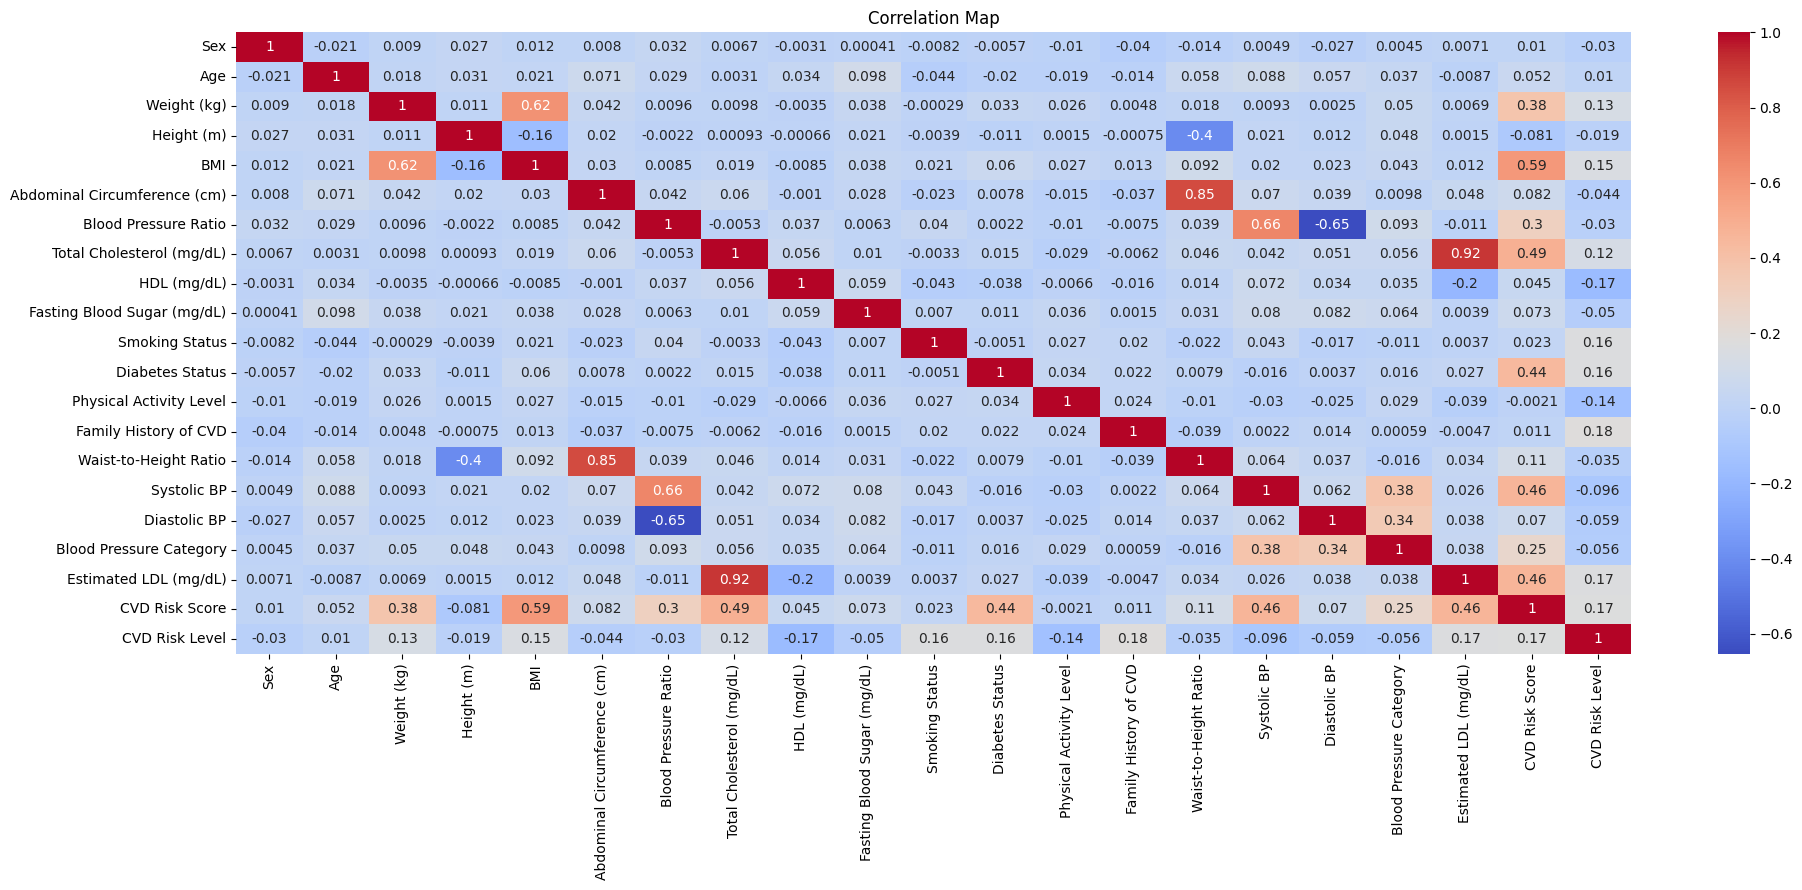

In [219]:
plt.figure(figsize=(20,9))
sns.heatmap(df.corr(),cmap='coolwarm',annot=True)
plt.title("Correlation Map")
plt.tight_layout()